# STEP 7. 보조질문 2 — 어떤 특성이 순감소 전환과 관련되는가

> **보조질문 2**: 매출·유동인구·점포 밀도 등 어떤 특성이 다음 분기 순감소 전환과 관련되는가?

STEP 6 이 **"한식이냐 아니냐"** 하나만 봤다면, 여기서는 **여러 특성을 동시에** 놓고 각각의 기여를 읽습니다.

## 두 가지를 합니다

| | 표본 | 목적 |
|---|---|---|
| **7-1 이중강건 추정** | 매칭 표본 (`06_matched.pkl`) | 매칭 위에 회귀를 한 번 더 얹어 ATT 를 재확인 |
| **7-3~7-6 설명 모형** | 골목상권 · **학습 분기만** | 보조질문 2 본론 |

## 왜 이중강건인가

매칭으로 조건을 맞추고, 그 위에서 회귀로 잔여 불균형을 한 번 더 보정합니다. **둘 중 하나가 틀려도 추정이 버팁니다** — 성향점수 모형이 잘못됐어도 결과 모형이 맞으면, 반대여도 마찬가지입니다.

## 누수 방지

설명 모형은 **`config.TRAIN_QUARTERS`(20231~20253) 만** 씁니다. 여기서 얻은 변수 선택·형태 판단이 STEP 8 예측 모형으로 넘어가는데, 검증 분기(20254)를 보고 정한 것이면 검증이 무의미해지기 때문입니다.

필요 패키지: `statsmodels` (군집 표준오차 때문에 필요합니다)


In [1]:
import sys, os
from pathlib import Path

# 노트북이 어디서 열리든 프로젝트 루트를 찾아 sys.path에 추가
ROOT = Path.cwd()
while not (ROOT / "config.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import numpy as np
import pandas as pd
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)
print("프로젝트 루트:", ROOT)

프로젝트 루트: c:\Users\spide\ai-data-bootcamp\project\h2_nb


In [2]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
from config import (PROC, FIG, TARGET_TYPE, COVARIATES, TRAIN_QUARTERS,
                    VALID_Q, SCORE_Q, set_korean_font)
set_korean_font()
OUT = FIG.parent
REF_SVC = "한식음식점"        # 업종 더미 기준 범주 — 모든 계수를 '한식 대비'로 읽는다

def fit_logit(frame, X, label=""):
    """군집(상권) 표준오차 로지스틱. 계수·오즈비·평균한계효과(AME)를 함께 반환"""
    X = sm.add_constant(X.astype(float), has_constant="add")
    m = sm.Logit(frame["y"].astype(int).values, X.values).fit(
        disp=0, cov_type="cluster", cov_kwds={"groups": frame["상권_코드"].values})
    p = m.predict(X.values)
    scale = (p * (1 - p)).mean()          # 로지스틱 평균한계효과 스케일
    res = pd.DataFrame({
        "계수": m.params, "표준오차": m.bse, "z": m.tvalues, "p값": m.pvalues,
        "오즈비": np.exp(m.params), "AME(%p)": m.params * scale * 100,
    }, index=X.columns)
    res.attrs["model"] = m
    res.attrs["label"] = label
    return res, m

matched = pd.read_pickle(PROC / "06_matched.pkl")
panel   = pd.read_pickle(PROC / "03_panel.pkl")
print(f"매칭 표본 {matched.shape} | 전체 패널 {panel.shape}")

매칭 표본 (14086, 42) | 전체 패널 (67475, 36)


## 7-1. 이중강건 추정

매칭 표본에서 `y ~ 처리 + 공변량 + 분기더미` 를 적합합니다. `처리` 계수가 잔여 불균형까지 보정한 효과입니다.

**g-계산(g-computation)** 으로 ATT 를 다시 냅니다 — 모든 행을 처리군으로 놓고 예측한 확률과 대조군으로 놓고 예측한 확률의 차이를 평균합니다. 계수를 확률 척도로 옮기는 정석적인 방법입니다.

In [3]:
X = pd.concat([
    matched[["처리"]],
    matched[COVARIATES],
    pd.get_dummies(matched["기준_년분기_코드"], prefix="q", drop_first=True),
], axis=1)

dr, m_dr = fit_logit(matched, X, "이중강건")
display(dr.loc[["처리"] + COVARIATES].round(4))

Xc = sm.add_constant(X.astype(float), has_constant="add")
X1 = Xc.copy(); X1["처리"] = 1.0
X0 = Xc.copy(); X0["처리"] = 0.0
att_dr = (m_dr.predict(X1.values) - m_dr.predict(X0.values)).mean()

pairs = matched.sort_values(["pair_id", "역할"])
y1 = pairs[pairs["역할"] == "처리"].sort_values("pair_id")["y"].to_numpy()
y0 = pairs[pairs["역할"] == "대조"].sort_values("pair_id")["y"].to_numpy()
att_match = (y1 - y0).mean()

print(f"매칭만으로 얻은 ATT   {att_match:+.2%}p   (STEP 6)")
print(f"이중강건 ATT          {att_dr:+.2%}p   (매칭 + 회귀 보정)")
print(f"차이                  {att_dr-att_match:+.2%}p")
print("\n※ 두 값이 가까우면 매칭이 이미 조건을 잘 맞췄다는 뜻입니다.")
print("   크게 벌어지면 잔여 불균형이 남아 있었다는 신호이므로 회귀 보정값을 씁니다.")

,계수,표준오차,z,p값,오즈비,AME(%p)
처리,-0.3343,0.0391,-8.5535,0.0000,0.7158,-6.1394
log_점포수,0.6603,0.0418,15.7945,0.0000,1.9353,12.1258
log_유동인구,0.0058,0.0260,0.2223,0.8241,1.0058,0.1063
log_면적,0.0051,0.0447,0.1146,0.9088,1.0051,0.0940
log_집객시설,0.0248,0.0351,0.7072,0.4794,1.0251,0.4559


매칭만으로 얻은 ATT   -5.76%p   (STEP 6)
이중강건 ATT          -6.14%p   (매칭 + 회귀 보정)
차이                  -0.38%p

※ 두 값이 가까우면 매칭이 이미 조건을 잘 맞췄다는 뜻입니다.
   크게 벌어지면 잔여 불균형이 남아 있었다는 신호이므로 회귀 보정값을 씁니다.


## 7-2. 대조군이 실제로 무엇인가

ATT 를 "한식 vs 기타 외식"이라고 부르지만, **매칭이 고른 대조군의 실제 구성**을 봐야 해석이 정확해집니다. 규모·유동인구를 맞추다 보면 특정 업종이 과대표집될 수 있습니다.

In [4]:
ctrl = matched[matched["역할"] == "대조"]
comp = (ctrl["서비스_업종_코드_명"].value_counts(normalize=True)
        .rename("매칭 대조군 비중").to_frame())
pool = (panel[(panel["상권유형"] == TARGET_TYPE) &
              (panel["서비스_업종_코드_명"] != REF_SVC)]["서비스_업종_코드_명"]
        .value_counts(normalize=True).rename("골목 대조군 풀 비중"))
comp = comp.join(pool)
comp["과대/과소"] = comp["매칭 대조군 비중"] / comp["골목 대조군 풀 비중"]
display(comp.round(3))
print(f"→ ATT 는 사실상 '{REF_SVC} vs "
      f"{comp.index[0]}·{comp.index[1]} 중심의 대조군' 비교입니다.")
print("   보고할 때 '기타 외식업 전체'라고 뭉뚱그리지 말아야 합니다.")

,매칭 대조군 비중,골목 대조군 풀 비중,과대/과소
서비스_업종_코드_명,,,
커피-음료,0.526,0.314,1.679
호프-간이주점,0.213,0.186,1.146
분식전문점,0.077,0.147,0.520
양식음식점,0.075,0.060,1.255
중식음식점,0.029,0.049,0.587
제과점,0.025,0.066,0.375
일식음식점,0.022,0.042,0.518
치킨전문점,0.020,0.078,0.254
패스트푸드점,0.013,0.058,0.231


→ ATT 는 사실상 '한식음식점 vs 커피-음료·호프-간이주점 중심의 대조군' 비교입니다.
   보고할 때 '기타 외식업 전체'라고 뭉뚱그리지 말아야 합니다.


## 7-3. 설명 모형 — 표본과 변수

- 표본: **골목상권 · 학습 분기(20231~20253)**
- 기준 범주: 업종은 `한식음식점`, 자치구·분기는 각각 첫 범주
- `점포밀도` 는 넣지 않습니다 — `log(밀도) = log(점포수) − log(면적)` 이라 이미 들어간 두 변수의 선형결합입니다
- `프랜차이즈_비율` 은 STEP 4 에서 비단조(Q2 정점)였으므로 **구간 더미**로 넣습니다

In [5]:
gm = panel[(panel["상권유형"] == TARGET_TYPE) &
           (panel["기준_년분기_코드"].isin(TRAIN_QUARTERS))].copy()
assert VALID_Q not in gm["기준_년분기_코드"].unique(), "검증 분기가 섞였습니다"
assert SCORE_Q not in gm["기준_년분기_코드"].unique()

gm["프랜차이즈구간"] = pd.cut(gm["프랜차이즈_비율"], [-0.001, 0, 0.2, 0.5, 1.001],
                            labels=["0%", "0~20%", "20~50%", "50%+"])

print(f"설명 모형 표본 {len(gm):,}행 | 분기 {gm['기준_년분기_코드'].min()}~{gm['기준_년분기_코드'].max()}")
print(f"상권 {gm['상권_코드'].nunique()}개 | 양성률 {gm['y'].mean():.1%}\n")
display(gm.groupby("프랜차이즈구간", observed=True)
        .agg(칸수=("y", "size"), 순감소율=("y", "mean")).round(3))

설명 모형 표본 31,875행 | 분기 20231~20253
상권 925개 | 양성률 23.6%



,칸수,순감소율
프랜차이즈구간,,
0%,9449,0.205
0~20%,13610,0.262
20~50%,6325,0.236
50%+,2491,0.211


### 모형을 단계적으로 쌓습니다

한 번에 다 넣으면 어떤 변수가 무엇을 설명하는지 알 수 없습니다. 하나씩 추가하며 계수가 어떻게 변하는지 봅니다.

| 모형 | 넣는 것 |
|---|---|
| A | 공변량 4개 + 분기 |
| B | A + 상권 특성(외식 비중, 프랜차이즈 구간) |
| C | B + 업종 더미 |
| D | C + 자치구 고정효과 |

In [6]:
def design(frame, svc=False, gu=False, extra=False):
    parts = [frame[COVARIATES]]
    if extra:
        parts.append(frame[["외식_비중"]])
        parts.append(pd.get_dummies(frame["프랜차이즈구간"], prefix="fr", drop_first=True))
    if svc:
        dum = pd.get_dummies(frame["서비스_업종_코드_명"], prefix="svc")
        parts.append(dum.drop(columns=[f"svc_{REF_SVC}"]))
    if gu:
        parts.append(pd.get_dummies(frame["자치구"], prefix="gu", drop_first=True))
    parts.append(pd.get_dummies(frame["기준_년분기_코드"], prefix="q", drop_first=True))
    return pd.concat(parts, axis=1)

models = {}
specs = [("A 기본",       dict()),
         ("B +상권특성",  dict(extra=True)),
         ("C +업종",      dict(extra=True, svc=True)),
         ("D +자치구",    dict(extra=True, svc=True, gu=True))]
for nm, kw in specs:
    models[nm] = fit_logit(gm, design(gm, **kw), nm)

summary = pd.DataFrame([{
    "모형": nm, "변수수": len(r) - 1, "pseudo R²": m.prsquared,
    "AIC": m.aic, "log_점포수 계수": r.loc["log_점포수", "계수"],
} for nm, (r, m) in models.items()])
display(summary.round(4))
print("※ log_점포수 계수가 모형을 늘려도 크게 안 변하면, 그 효과가 다른 변수로 설명되지 않는다는 뜻입니다.")

,모형,변수수,pseudo R²,AIC,log_점포수 계수
0,A 기본,14,0.0291,33855.2666,0.5700
1,B +상권특성,18,0.0297,33843.8979,0.6065
2,C +업종,27,0.0333,33735.2845,0.8077
3,D +자치구,51,0.0349,33727.4638,0.8246


※ log_점포수 계수가 모형을 늘려도 크게 안 변하면, 그 효과가 다른 변수로 설명되지 않는다는 뜻입니다.


## 7-4. 최종 모형 계수

**AME(평균한계효과)** 는 계수를 확률 척도로 옮긴 값입니다. "이 변수가 1 단위 늘면 순감소 확률이 몇 %p 변하는가"로 바로 읽힙니다. 오즈비보다 해석이 직관적입니다.

표준오차는 **상권 단위 군집**으로 계산합니다 — 같은 상권이 최대 11분기 반복 관측되므로 일반 표준오차는 과소 추정됩니다.

In [7]:
res, m_final = models["D +자치구"]
show = [c for c in res.index if not c.startswith(("gu_", "q_"))]
tbl = res.loc[show].copy()
tbl["유의"] = pd.cut(tbl["p값"], [0, .001, .01, .05, 1], labels=["***", "**", "*", ""])
display(tbl.round(4))
print(f"n = {int(m_final.nobs):,} | 상권 {gm['상권_코드'].nunique()}개 군집 | "
      f"pseudo R² = {m_final.prsquared:.4f}")
print(f"자치구 더미 {sum(c.startswith('gu_') for c in res.index)}개, "
      f"분기 더미 {sum(c.startswith('q_') for c in res.index)}개는 생략")

,계수,표준오차,z,p값,오즈비,AME(%p),유의
const,-2.7751,0.3581,-7.7491,0.0000,0.0623,-48.0575,***
log_점포수,0.8246,0.0302,27.3149,0.0000,2.2810,14.2803,***
log_유동인구,0.0416,0.0236,1.7646,0.0776,1.0425,0.7204,
log_면적,-0.0800,0.0372,-2.1505,0.0315,0.9231,-1.3853,*
log_집객시설,-0.0717,0.0277,-2.5856,0.0097,0.9308,-1.2423,**
외식_비중,-0.7992,0.1754,-4.5573,0.0000,0.4497,-13.8395,***
fr_0~20%,-0.0602,0.0355,-1.6950,0.0901,0.9416,-1.0427,
fr_20~50%,-0.0039,0.0431,-0.0896,0.9286,0.9961,-0.0669,
fr_50%+,-0.0612,0.0791,-0.7741,0.4389,0.9406,-1.0600,
svc_분식전문점,0.5351,0.0603,8.8742,0.0000,1.7076,9.2662,***


n = 31,875 | 상권 925개 군집 | pseudo R² = 0.0349
자치구 더미 24개, 분기 더미 10개는 생략


In [8]:
print("[크기 순 정렬 — 무엇이 가장 크게 관련되는가]")
imp = (tbl[tbl.index != "const"]
       .assign(절대AME=lambda x: x["AME(%p)"].abs())
       .sort_values("절대AME", ascending=False)[["AME(%p)", "p값", "유의"]])
display(imp.round(4))

[크기 순 정렬 — 무엇이 가장 크게 관련되는가]


,AME(%p),p값,유의
log_점포수,14.2803,0.0000,***
svc_패스트푸드점,13.8863,0.0000,***
외식_비중,-13.8395,0.0000,***
svc_치킨전문점,10.5637,0.0000,***
svc_일식음식점,10.0495,0.0000,***
svc_제과점,9.5367,0.0000,***
svc_분식전문점,9.2662,0.0000,***
svc_양식음식점,8.0184,0.0000,***
svc_호프-간이주점,6.9543,0.0000,***
svc_커피-음료,6.4412,0.0000,***


## 7-5. 업종 효과 — PSM 결과와 대조

업종 더미는 모두 **한식 대비**입니다. 공변량을 통제한 상태에서 한식보다 위험하면 (+), 안전하면 (−) 입니다.

STEP 6 의 ATT(−5.8%p)는 "한식이 조건이 같은 타 업종보다 5.8%p 안전하다"였습니다. **여기서 업종 더미가 대체로 (+) 로 나오면 두 방법이 같은 결론에 도달한 것입니다.**

In [9]:
svc_rows = [c for c in res.index if c.startswith("svc_")]
sv = res.loc[svc_rows, ["계수", "오즈비", "AME(%p)", "p값"]].copy()
sv.index = [c.replace("svc_", "") for c in sv.index]
sv = sv.sort_values("AME(%p)", ascending=False)
display(sv.round(4))
print(f"기준 범주 : {REF_SVC} (AME 0)")
print(f"한식보다 위험한 업종 {(sv['AME(%p)'] > 0).sum()}개 / "
      f"안전한 업종 {(sv['AME(%p)'] < 0).sum()}개")
print(f"\nSTEP 6 ATT (한식 − 대조) : {att_match:+.2%}p")
print(f"설명 모형 업종 더미 평균  : {-sv['AME(%p)'].mean()/100:+.2%}p  (부호를 맞추려 뒤집음)")
print("→ 두 방법이 같은 방향을 가리키면 결론이 방법에 의존하지 않는다는 뜻입니다.")

,계수,오즈비,AME(%p),p값
패스트푸드점,0.8019,2.2297,13.8863,0.0000
치킨전문점,0.6100,1.8405,10.5637,0.0000
일식음식점,0.5803,1.7866,10.0495,0.0000
제과점,0.5507,1.7345,9.5367,0.0000
분식전문점,0.5351,1.7076,9.2662,0.0000
양식음식점,0.4630,1.5889,8.0184,0.0000
호프-간이주점,0.4016,1.4942,6.9543,0.0000
커피-음료,0.3720,1.4506,6.4412,0.0000
중식음식점,0.3385,1.4029,5.8622,0.0001


기준 범주 : 한식음식점 (AME 0)
한식보다 위험한 업종 9개 / 안전한 업종 0개

STEP 6 ATT (한식 − 대조) : -5.76%p
설명 모형 업종 더미 평균  : -8.95%p  (부호를 맞추려 뒤집음)
→ 두 방법이 같은 방향을 가리키면 결론이 방법에 의존하지 않는다는 뜻입니다.


## 7-6. 매출 — 관측 부분표본

매출은 점포 2개 이하 칸이 비식별 처리되어 비어 있고, 분석 표본에서도 업종마다 관측률이 다릅니다. 그래서 **주 모형에서 빼고 여기서 따로** 봅니다.

매출은 업종의 *결과*이기도 하므로(한식과 카페는 사업 모형이 다름) 계수를 인과적으로 읽으면 안 됩니다. **"매출이 낮은 칸이 위험하더라"는 연관 관계**로만 읽습니다.

In [10]:
sub = gm[gm["매출_관측"]].copy()
sub["log_매출"]     = np.log1p(sub["당월_매출_금액"])
sub["log_점포당매출"] = np.log1p(sub["점포당매출"])
print(f"매출 관측 표본 {len(sub):,} / {len(gm):,} ({len(sub)/len(gm):.1%})\n")

Xs = pd.concat([design(sub, extra=True, svc=True, gu=True),
                sub[["log_점포당매출"]]], axis=1)
res_s, m_s = fit_logit(sub, Xs, "매출 포함")
show_s = [c for c in res_s.index if not c.startswith(("gu_", "q_", "svc_"))]
display(res_s.loc[show_s].round(4))
print(f"pseudo R²  매출 없이 {m_final.prsquared:.4f} → 매출 포함 {m_s.prsquared:.4f}")
print("※ 점포당매출을 넣어도 설명력이 거의 안 오르면, 규모 변수가 이미 그 정보를 담고 있다는 뜻입니다.")

매출 관측 표본 28,976 / 31,875 (90.9%)



,계수,표준오차,z,p값,오즈비,AME(%p)
const,0.0117,0.4492,0.0260,0.9793,1.0117,0.2020
log_점포수,0.8999,0.0317,28.4034,0.0000,2.4594,15.5837
log_유동인구,0.0432,0.0250,1.7295,0.0837,1.0441,0.7478
log_면적,-0.1458,0.0381,-3.8243,0.0001,0.8644,-2.5241
log_집객시설,-0.0565,0.0286,-1.9747,0.0483,0.9451,-0.9776
외식_비중,-0.6905,0.1743,-3.9619,0.0001,0.5013,-11.9573
fr_0~20%,-0.0401,0.0381,-1.0520,0.2928,0.9607,-0.6945
fr_20~50%,0.0725,0.0464,1.5609,0.1186,1.0752,1.2551
fr_50%+,0.0326,0.0924,0.3526,0.7244,1.0331,0.5640
log_점포당매출,-0.1266,0.0146,-8.7003,0.0000,0.8811,-2.1922


pseudo R²  매출 없이 0.0349 → 매출 포함 0.0404
※ 점포당매출을 넣어도 설명력이 거의 안 오르면, 규모 변수가 이미 그 정보를 담고 있다는 뜻입니다.


## 7-7. 시각화

C:\Users\spide\AppData\Local\Temp\ipykernel_27488\316584770.py:41: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\spide\AppData\Local\Temp\ipykernel_27488\316584770.py:42: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.savefig(FIG / "step7_explain.png", dpi=130)
c:\Users\spide\anaconda3\envs\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


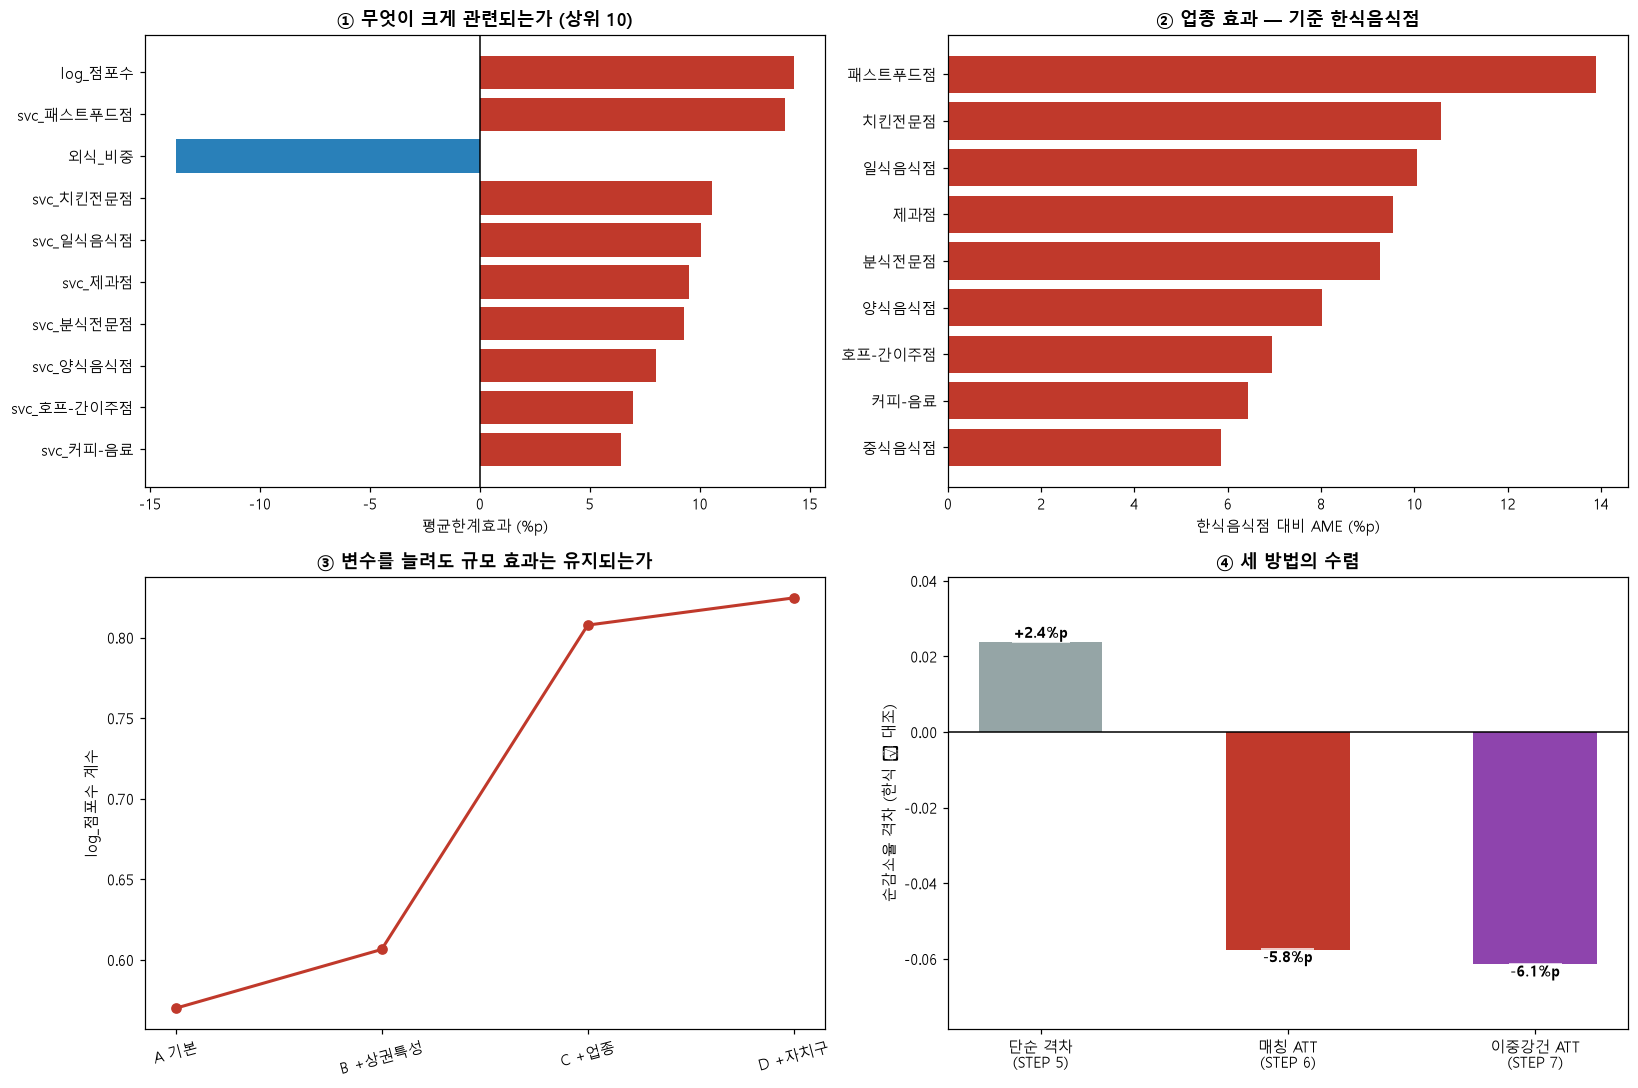

In [11]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# ① AME 크기 순
top = imp.head(10).iloc[::-1]
cols = ["#c0392b" if v > 0 else "#2980b9" for v in top["AME(%p)"]]
ax[0,0].barh(top.index, top["AME(%p)"], color=cols)
ax[0,0].axvline(0, c="k", lw=1)
ax[0,0].set_xlabel("평균한계효과 (%p)")
ax[0,0].set_title("① 무엇이 크게 관련되는가 (상위 10)", weight="bold")

# ② 업종 더미
sv2 = sv.sort_values("AME(%p)")
ax[0,1].barh(sv2.index, sv2["AME(%p)"],
             color=["#c0392b" if v > 0 else "#2980b9" for v in sv2["AME(%p)"]])
ax[0,1].axvline(0, c="k", lw=1)
ax[0,1].set_xlabel(f"{REF_SVC} 대비 AME (%p)")
ax[0,1].set_title(f"② 업종 효과 — 기준 {REF_SVC}", weight="bold")

# ③ 모형 단계별 log_점포수 계수
ax[1,0].plot(summary["모형"], summary["log_점포수 계수"], marker="o", color="#c0392b", lw=2)
ax[1,0].set_ylabel("log_점포수 계수"); ax[1,0].tick_params(axis="x", rotation=15)
ax[1,0].set_title("③ 변수를 늘려도 규모 효과는 유지되는가", weight="bold")

# ④ 매칭 ATT vs 이중강건
labels = ["단순 격차\n(STEP 5)", "매칭 ATT\n(STEP 6)", "이중강건 ATT\n(STEP 7)"]
gap0 = (panel[(panel["상권유형"]==TARGET_TYPE)].pipe(
    lambda f: f.loc[f["서비스_업종_코드_명"]==REF_SVC, "y"].mean()
              - f.loc[f["서비스_업종_코드_명"]!=REF_SVC, "y"].mean()))
vals = [gap0, att_match, att_dr]
bars = ax[1,1].bar(labels, vals, width=.5,
                   color=["#95a5a6", "#c0392b", "#8e44ad"])
ax[1,1].axhline(0, c="k", lw=1)
ax[1,1].margins(y=0.20)
for b, v in zip(bars, vals):
    ax[1,1].text(b.get_x()+b.get_width()/2, v, f"{v:+.1%}p", ha="center",
                 va="bottom" if v > 0 else "top", weight="bold",
                 bbox=dict(fc="white", ec="none", alpha=.75, pad=1))
ax[1,1].set_ylabel("순감소율 격차 (한식 − 대조)")
ax[1,1].set_title("④ 세 방법의 수렴", weight="bold")

plt.tight_layout()
plt.savefig(FIG / "step7_explain.png", dpi=130)
plt.show()

## 7-8. 저장 및 정리

In [12]:
imp.to_csv(OUT / "q2_effects.csv", encoding="utf-8-sig")
sv.to_csv(OUT / "q2_service_effects.csv", encoding="utf-8-sig")
print("[저장] outputs/q2_effects.csv, q2_service_effects.csv")
print("[저장] figures/step7_explain.png\n")

print("── 보조질문 2 답변 요지 ──────────────")
for i, (nm, row) in enumerate(imp.head(5).iterrows(), 1):
    d_ = "높일수록 위험" if row["AME(%p)"] > 0 else "높을수록 안전"
    print(f"  {i}. {nm:16} {row['AME(%p)']:+7.2f}%p  {d_} {row['유의']}")
print()
print("── STEP 8 로 넘길 것 ─────────────────")
print(f"  학습 분기 : {TRAIN_QUARTERS[0]} ~ {TRAIN_QUARTERS[-1]} (검증 {VALID_Q} 제외 확인 완료)")
print(f"  베이스라인 pseudo R² : {m_final.prsquared:.4f} — 예측 모형이 이보다 나아야 의미 있음")
print("  변수 형태 판단 : 프랜차이즈는 구간 더미, 점포밀도는 제외(공선성)")

[저장] outputs/q2_effects.csv, q2_service_effects.csv
[저장] figures/step7_explain.png

── 보조질문 2 답변 요지 ──────────────
  1. log_점포수           +14.28%p  높일수록 위험 ***
  2. svc_패스트푸드점        +13.89%p  높일수록 위험 ***
  3. 외식_비중             -13.84%p  높을수록 안전 ***
  4. svc_치킨전문점         +10.56%p  높일수록 위험 ***
  5. svc_일식음식점         +10.05%p  높일수록 위험 ***

── STEP 8 로 넘길 것 ─────────────────
  학습 분기 : 20231 ~ 20253 (검증 20254 제외 확인 완료)
  베이스라인 pseudo R² : 0.0349 — 예측 모형이 이보다 나아야 의미 있음
  변수 형태 판단 : 프랜차이즈는 구간 더미, 점포밀도는 제외(공선성)


---

## STEP 8 에서 할 일 (예측)

- 학습 `TRAIN_QUARTERS`(20231~20253) → 검증 `VALID_Q`(20254, 타깃 20261)
- 베이스라인 순서: 다수 클래스 → 직전 분기 상태 → 로지스틱 → 트리/부스팅
- 평가는 **AUC · PR-AUC · Brier**. 양성률 25% 라 정확도는 무의미
- 확률 보정(calibration) 확인 — 자치구별 업종 순위를 매기려면 확률값 자체가 믿을 만해야 함
- 롤링 오리진 검증으로 분기 간 성능 변동 확인
